In [31]:
import numpy as np 
from sklearn.cluster import DBSCAN 
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt 

## Create random data and Standardize features

In [32]:
def createDataPoints (centroidLocation,numSamples,clusterDeviation):
    x,y=make_blobs(n_samples=numSamples,centers=centroidLocation,
                               cluster_std=clusterDeviation)

    x=StandardScaler().fit_transform(x)
    return x,y


## create data points

In [33]:
x,y=createDataPoints([[4,3],[2,-1],[-1,4]],1500,0.5)

### Modeling

In [34]:
epsilon=0.3
minimumSamples=7
db=DBSCAN(eps=epsilon, min_samples=minimumSamples).fit(x)
labels=db.labels_
labels

array([0, 1, 0, ..., 0, 1, 2], dtype=int64)

### Distinguish outliers

Let's Replace all elements with 'True' in core_samples_mask that are in the cluster, 'False' if the points are outliers.

In [35]:
core_samples_mask=np.zeros_like(db.labels_,dtype=bool)
core_samples_mask[db.core_sample_indices_]=True
core_samples_mask

array([ True,  True,  True, ...,  True,  True,  True])

In [36]:
print(labels)
print(set(labels))
print(len(set(labels)))

[0 1 0 ... 0 1 2]
{0, 1, 2, -1}
4


In [37]:
# Remove repetition in labels by turning it into a set.
unique_labels=set(labels)
unique_labels

{-1, 0, 1, 2}

In [38]:
# Number of clusters in labels, ignoring noise if present.
n_clusters_=len(set(labels))-(1 if -1 in labels else 0)
n_clusters_

3

### Data visualization

In [39]:
# Create colors for the clusters.
colors=plt.cm.Spectral(np.linspace(0,1,len(unique_labels)))
colors

array([[0.61960784, 0.00392157, 0.25882353, 1.        ],
       [0.99346405, 0.74771242, 0.43529412, 1.        ],
       [0.74771242, 0.89803922, 0.62745098, 1.        ],
       [0.36862745, 0.30980392, 0.63529412, 1.        ]])

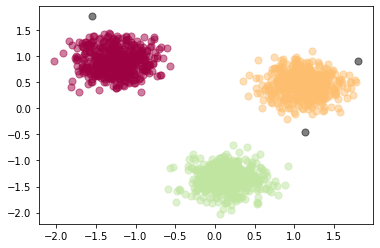

In [40]:
for k,col in zip(unique_labels,colors):
    if k==-1:
         # Black used for noise.
         col='k'

    class_member_mask=(labels==k)

    # Plot the datapoints that are clustered
    xy=x[class_member_mask & core_samples_mask]
    plt.scatter(xy[:,0], xy[:,1], s=50 ,c=[col], marker=u'o',alpha=0.5)

    # Plot the borders
    xy=x[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:,0] , xy[:,1], s=50, c=[col], marker=u'o', alpha=0.5)
